# Implementing a VAE for Anomaly Detection | تنفيذ VAE لكشف الشذوذ

## 📚 Learning Objectives | أهداف التعلم

By completing this notebook (~20 min), you will:
- Build a **VAE** (encoder → mean/log_var → sample latent → decoder) and train it on MNIST
- Use **reconstruction error** as an **anomaly score** (high error = likely anomaly)
- See why we use a VAE (instead of a plain autoencoder) for a probabilistic latent and anomaly detection

---

## 🌍 Real life | في الواقع

**Where is this used?** VAEs are used for **anomaly detection** (fraud, faulty sensors), **generative models**, and **compression** with uncertainty.

**In this notebook we use** a **VAE** to learn a **probabilistic latent** (mean + variance) and **reconstruct** images. We use **reconstruction error** as an anomaly score. We use **VAE** (instead of a plain autoencoder) **because** the latent is **regularized** (KL divergence) so it generalizes; anomalies often have **high reconstruction error**.

---

**Before starting:** Run the imports cell below.

## Theory (short) | النظرية

- **VAE:** Encoder outputs **mean** and **log-variance** of the latent; we **sample** z ~ N(mean, var) and decode. Loss = reconstruction (e.g. BCE) + **KL(prior || posterior)** to regularize the latent.
- **Anomaly detection:** Train VAE on **normal** data; at test time, **high reconstruction error** (or high KL) suggests an **anomaly**.
- **We use VAE** instead of a plain autoencoder when we want a **probabilistic** latent and better generalization; the KL term prevents overfitting to the training set.

## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple VAE (dense layers).

**Dataset:** Real — MNIST (small subset).

**Outputs:** Training loss (reconstruction + KL), one figure: **original vs reconstructed** (with axis labels), and a short note on using reconstruction error for anomaly detection.

## Step 1: Imports and load MNIST

In [4]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:5000]
    x_test = x_test.reshape(-1, 784)[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build VAE (we use sampling layer so latent is probabilistic; we use VAE instead of AE for regularized latent)

In [5]:
if HAS_TF:
    latent_dim = 16
    class Sampling(keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            eps = tf.random.normal(shape=(batch, latent_dim))
            return z_mean + tf.exp(0.5 * z_log_var) * eps

    encoder_inp = keras.Input(shape=(784,))
    x = keras.layers.Dense(128, activation="relu")(encoder_inp)
    z_mean = keras.layers.Dense(latent_dim)(x)
    z_log_var = keras.layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inp, [z_mean, z_log_var, z])

    decoder_inp = keras.Input(shape=(latent_dim,))
    d = keras.layers.Dense(128, activation="relu")(decoder_inp)
    d = keras.layers.Dense(784, activation="sigmoid")(d)
    decoder = keras.Model(decoder_inp, d)

    vae_inp = keras.Input(shape=(784,))
    z_mean, z_log_var, z = encoder(vae_inp)
    vae_out = decoder(z)
    # Total VAE loss = reconstruction + KL (same as in theory). We add KL via add_loss and use recon_loss below so Keras is happy.
    kl = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
    vae = keras.Model(vae_inp, vae_out)
    vae.add_loss(tf.reduce_mean(kl))

    def recon_loss(y_true, y_pred):
        return tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(y_true, y_pred), axis=-1))

    vae.compile(optimizer="adam", loss=recon_loss)
    vae.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 784)]                0         []                            
                                                                                                  
 model_3 (Functional)        [(None, 16),                 104608    ['input_6[0][0]']             
                              (None, 16),                                                         
                              (None, 16)]                                                         
                                                                                                  
 model_4 (Functional)        (None, 784)                  103312    ['model_3[0][2]']             
                                                                                            

## Step 3: Train (2 epochs) and plot original vs reconstructed

Epoch 1/2
40/40 [==============================] - 0s 3ms/step - loss: 65.0967 - val_loss: 43.1674
Epoch 2/2
40/40 [==============================] - 0s 2ms/step - loss: 40.2344 - val_loss: 37.0132


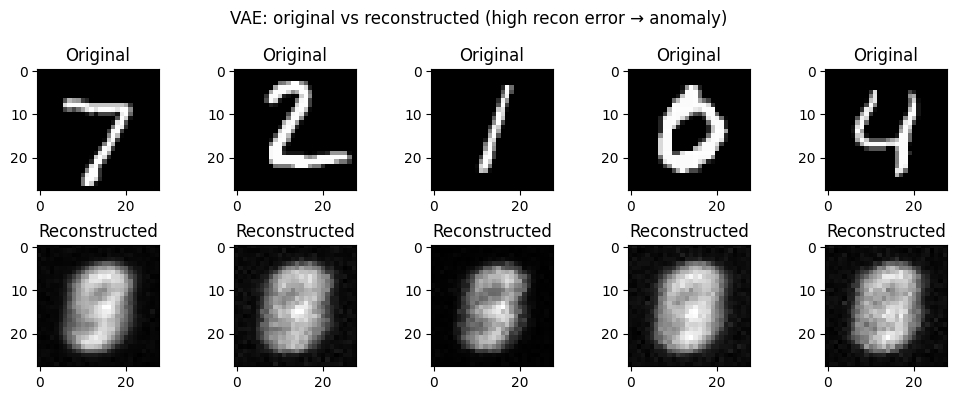

For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.


In [6]:
if HAS_TF:
    history = vae.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=2, batch_size=128, verbose=1)
    recons = vae.predict(x_test[:5], verbose=0)
    fig, axs = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
        axs[0, i].set_title("Original")
        axs[0, i].set_xlabel("")
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray")
        axs[1, i].set_title("Reconstructed")
        axs[1, i].set_xlabel("")
    plt.suptitle("VAE: original vs reconstructed (high recon error → anomaly)")
    plt.tight_layout()
    plt.show()
    print("For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.")

## 🧩 Mini-exercise | تمرين مصغر

**Try it:** In a new cell, compute the reconstruction error (e.g. MSE) for 5 test images and print them. Which image has the highest error? (That could be an "anomaly" if you had trained on normal-only data.)

---

## ✅ Summary | الملخص

**What you did:** Built a VAE (encoder → mean/log_var → sample → decoder), trained it on MNIST, and plotted original vs reconstructed. Reconstruction error can be used as an anomaly score.

**In real life you'd also:** Train on normal-only data, set a threshold on reconstruction error, and evaluate on a dataset with labeled anomalies.

**The main idea:** VAE learns a probabilistic latent; high reconstruction error at test time suggests the sample is an anomaly (e.g. not from the training distribution).

**Next:** `01_gans_and_autoencoders_vaes` covers autoencoders and GANs; `04_ethical_concerns_in_ai_bias_fairness_interpretability` covers bias and fairness.